In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pybamm

# 1. Setup DFN Model and Parameters

In [4]:
parameter_values = pybamm.ParameterValues("Mohtat2020")
parameter_values.update(
    {

        # Thermal-lumped and surface temperature-lumped
        #"Cell thermal capacity [J.K-1]": 1200.0,
        "Casing heat capacity [J.K-1]": 300.0,
        "Environment thermal resistance [K.W-1]": 2.0,
        #"Internal thermal resistance [K.W-1]": 0.2,

        # Lithium plating parameters
        "Lithium plating transfer coefficient": 0.5,
        # "Dead Lithium decay constants [s-1]": 1e-4,
        "Exchange-current density for stripping [A.m-2]": 0.1,
        #"Dead lithium decay rate [s-1]": 1e-4
    },
    check_already_exists=False
)

In [111]:
parameter_values

{'Ambient temperature [K]': 298.15,
 'Bulk solvent concentration [mol.m-3]': 2636.0,
 'Casing heat capacity [J.K-1]': 300.0,
 'Cation transference number': 0.38,
 'Cell cooling surface area [m2]': 0.41,
 'Cell volume [m3]': 3.92e-05,
 'Contact resistance [Ohm]': 0,
 'Current function [A]': 5.0,
 'EC diffusivity [m2.s-1]': 2e-18,
 'EC initial concentration in electrolyte [mol.m-3]': 4541.0,
 'Edge heat transfer coefficient [W.m-2.K-1]': 5.0,
 'Electrode height [m]': 1.0,
 'Electrode width [m]': 0.205,
 'Electrolyte conductivity [S.m-1]': <function electrolyte_conductivity_PeymanMPM at 0x79379a8071a0>,
 'Electrolyte diffusivity [m2.s-1]': <function electrolyte_diffusivity_PeymanMPM at 0x79379a806a20>,
 'Environment thermal resistance [K.W-1]': 2.0,
 'Exchange-current density for plating [A.m-2]': 0.001,
 'Exchange-current density for stripping [A.m-2]': 0.1,
 'Initial SEI thickness [m]': 5e-09,
 'Initial concentration in electrolyte [mol.m-3]': 1000.0,
 'Initial concentration in negative

In [241]:
def run_formation(experiment, parameter_values, last_state):
  model = pybamm.lithium_ion.DFN(options={
      "open-circuit potential": "single",
      "intercalation kinetics": "symmetric Butler-Volmer",
      "thermal": "lumped",
      "surface form": "algebraic",
      "surface temperature": "lumped",
      "SEI": "ec reaction limited",
      "SEI film resistance": "distributed",
      "SEI porosity change": "false",
      "lithium plating": "reversible",
      "lithium plating porosity change": "true",
      }
  )

  solver = pybamm.IDAKLUSolver(rtol=1e-6, atol=1e-6)

  sim = pybamm.Simulation(model, experiment=experiment, parameter_values=parameter_values, solver=solver)
  sol = sim.solve(starting_solution=last_state if last_state is not None else None)

  return sol


In [194]:
step1 = pybamm.Experiment(
    [(
      "Rest for 5 minutes",
      "Charge at 0.05C for 100 minutes",
      "Rest for 4320 minutes",
)])

step2 = pybamm.Experiment(
    [(
      "Charge at 0.1C until 4.1V",
      "Discharge at 0.1C until 2.5V",
    ) * 4,
    ])

In [195]:
sol1 = run_formation(step1, parameter_values, None)
sol2 = run_formation(step2, parameter_values, sol1.last_state)

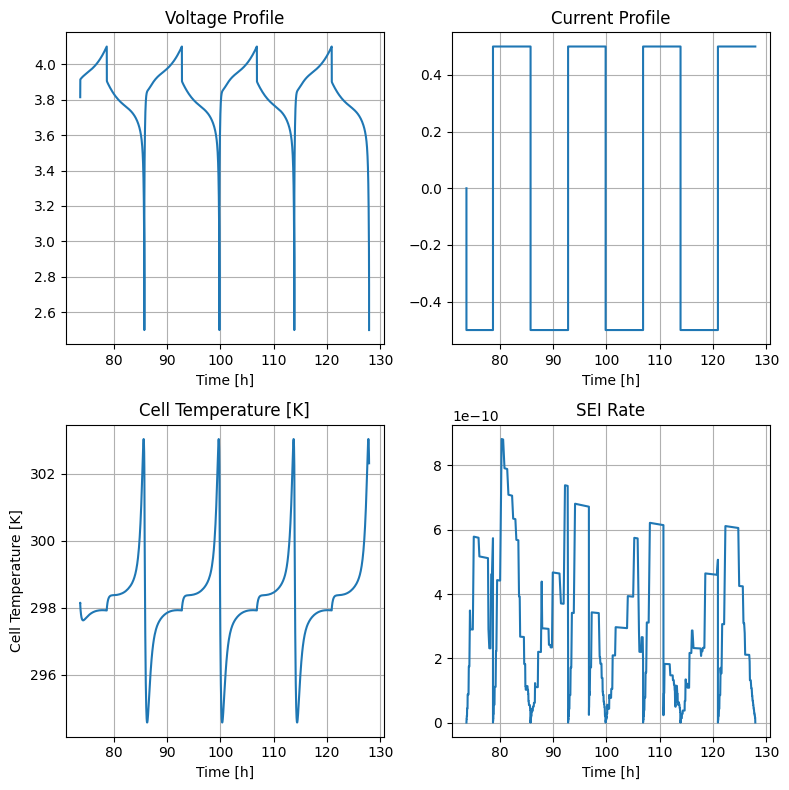

In [196]:
fig, ax = plt.subplots(2,2, figsize=(8,8))
ax[0,0].plot(sol2["Time [h]"].entries, sol2["Terminal voltage [V]"].entries)
ax[0,0].set_title("Voltage Profile")
ax[0,0].set_xlabel("Time [h]")
#ax[0,0].set_ylabel("Voltage [V]")
ax[0,0].grid()

ax[0,1].plot(sol2["Time [h]"].entries, sol2["Current [A]"].entries)
ax[0,1].set_title("Current Profile")
ax[0,1].set_xlabel("Time [h]")
#ax[0,1].set_ylabel("Current [A]")
ax[0,1].grid()


ax[1,0].plot(sol2["Time [h]"].entries, np.mean(sol2[ 'Cell temperature [K]'].entries,axis=0))
ax[1,0].set_title("Cell Temperature [K]")
ax[1,0].set_xlabel("Time [h]")
ax[1,0].set_ylabel("Cell Temperature [K]")
ax[1,0].grid()

sei_rate = np.diff(sol2['X-averaged negative SEI thickness [m]'].entries)
sei_rate = np.insert(sei_rate, 0, 0.0 )

ax[1,1].plot(sol2["Time [h]"].entries, sei_rate)
ax[1,1].set_title("SEI Rate")
ax[1,1].set_xlabel("Time [h]")
#ax[1,1].set_ylabel("Negative SEI thickness [m]")
ax[1,1].grid()



plt.tight_layout()
#plt.grid(True)
plt.show()

In [242]:
aging1 = pybamm.Experiment([
            (
                "Charge at 0.5C until 4.0V",
                "Hold at 4.0V until C/10",
                "Discharge at 0.5C until 2.8V"
            ) * 100,
            #termination="80% capacity"
        ])

asol1 = run_formation(aging1, parameter_values, sol2.last_state)


2026-06-02 13:40:10.125 - [ERROR] callbacks.on_experiment_error(235): Simulation error: IDA_ERR_FAIL: Error test failures occurred too many times during one step or minimum step size was reached


In [237]:
aging2 = pybamm.Experiment([
            (
                "Charge at 1C until 4.0V",
                "Hold at 4.0V until C/10",
                "Discharge at 1C until 2.8V"
            ) * 100,
            #termination="80% capacity"
        ])

asol2 = run_formation(aging2, parameter_values, sol2.last_state)

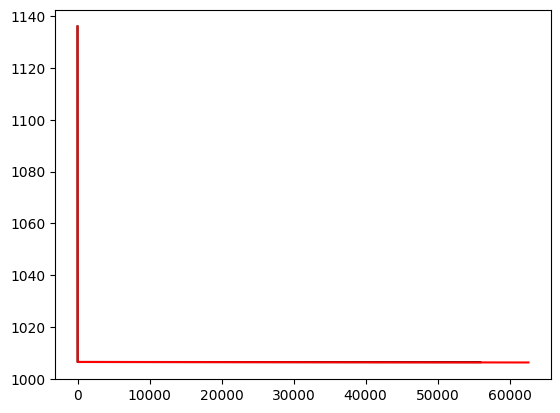

In [238]:
val = "X-averaged electrolyte concentration [mol.m-3]"
plt.figure()
plt.plot(asol1[val].entries, c="black")
plt.plot(asol2[val].entries, c="red")
plt.show()

In [230]:
val = "Negative electrode porosity"
print(asol1[val].entries[:,-1])
print("\n----------------\n")
print(asol1[val].entries[:,0])
# print(asol2[val].entries[:,:,-1])
# print(min(asol1[val].entries[-1]), max(asol1[val].entries[-1]))
# print(min(asol2[val].entries[-1]), max(asol2[val].entries[-1])

[0.05899624 0.06028442 0.06247852 0.06532104 0.06866751 0.07242851
 0.07654028 0.08095495 0.08563602 0.09055494 0.09568857 0.10101655
 0.10651674 0.11216992 0.11796681 0.1239037  0.1299803  0.13619811
 0.14255889 0.14906332]

----------------

[0.21627897 0.21628009 0.21628214 0.21628514 0.2162891  0.21629404
 0.21629998 0.21630697 0.21631503 0.21632421 0.21633456 0.21634614
 0.216359   0.21637322 0.21638887 0.21640602 0.21642477 0.21644522
 0.21646747 0.21649162]


In [229]:
asol1[val].entries.shape

(20, 17892)

In [225]:
for key in asol1.all_models[0].variables.keys():
    if "porosity" in key.lower():
        print(key)

Porosity times concentration [mol.m-3]
Negative electrode porosity times concentration [mol.m-3]
Separator porosity times concentration [mol.m-3]
Positive electrode porosity times concentration [mol.m-3]
Porosity
Negative electrode porosity
X-averaged negative electrode porosity
Separator porosity
X-averaged separator porosity
Positive electrode porosity
X-averaged positive electrode porosity


In [ ]:
sol3["Dis"].entries

array([1136.05143793, 1136.05143793, 1136.05127656, ..., 1494.26297636,
       1497.22189285, 1498.23972972])

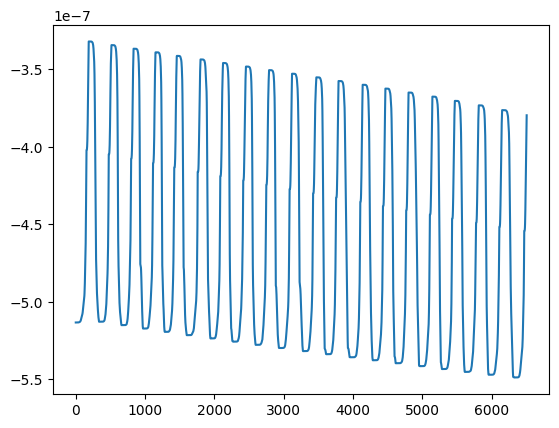

In [55]:
plt.figure()
plt.plot(sol3["X-averaged negative lithium plating thickness [m]"].entries)
plt.show()


